# Laboratorio 2: modelos LSTM para series de tiempo

**Curso:** CC3084 - Data Science  
**Integrantes:** Osman de León, Milton Polanco  
**Fecha:** 30 de julio de 2026

En esta primera parte trabajamos con dos series del laboratorio anterior: el total mensual de viajeros y la región América del Norte. Para cada serie se probaron modelos LSTM con configuraciones distintas y se realizó un tuneo de parámetros.

In [1]:
import os
import random
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
warnings.filterwarnings("ignore")

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

SEMILLA = 42
BASE = Path.cwd().resolve()
if BASE.name == "notebooks":
    BASE = BASE.parent

## 1. Preparación de los datos

Se utilizó el mismo filtro del Laboratorio 1: turistas y excursionistas. También se conservó la división cronológica de 70% para entrenamiento y 30% para prueba. Esto permite comparar posteriormente los resultados con los modelos anteriores.

In [2]:
ruta_datos = BASE / "data" / "raw" / "Base_Migracion_2009-2026jun.xlsx"
df = pd.read_excel(ruta_datos)
df["Fecha"] = pd.to_datetime(
    {"year": df["Año"], "month": df["Mes cod"], "day": 1}
)

turismo = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])].copy()

series = {
    "Total mensual de viajeros": (
        turismo.groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    ),
    "Región: América del Norte": (
        turismo[turismo["Región dos"] == "América Del Norte"]
        .groupby("Fecha")["Viajero"]
        .sum()
        .asfreq("MS")
        .fillna(0)
    ),
}

def dividir_serie(serie, proporcion=0.70):
    corte = int(len(serie) * proporcion)
    return serie.iloc[:corte].copy(), serie.iloc[corte:].copy()

resumen_series = []
for nombre, serie in series.items():
    train, test = dividir_serie(serie)
    resumen_series.append({
        "Serie": nombre,
        "Total": len(serie),
        "Train": len(train),
        "Fin de train": train.index.max().strftime("%Y-%m"),
        "Test": len(test),
        "Inicio de test": test.index.min().strftime("%Y-%m"),
    })

pd.DataFrame(resumen_series)

,Serie,Total,Train,Fin de train,Test,Inicio de test
0,Total mensual de viajeros,210,147,2021-03,63,2021-04
1,Región: América del Norte,210,147,2021-03,63,2021-04


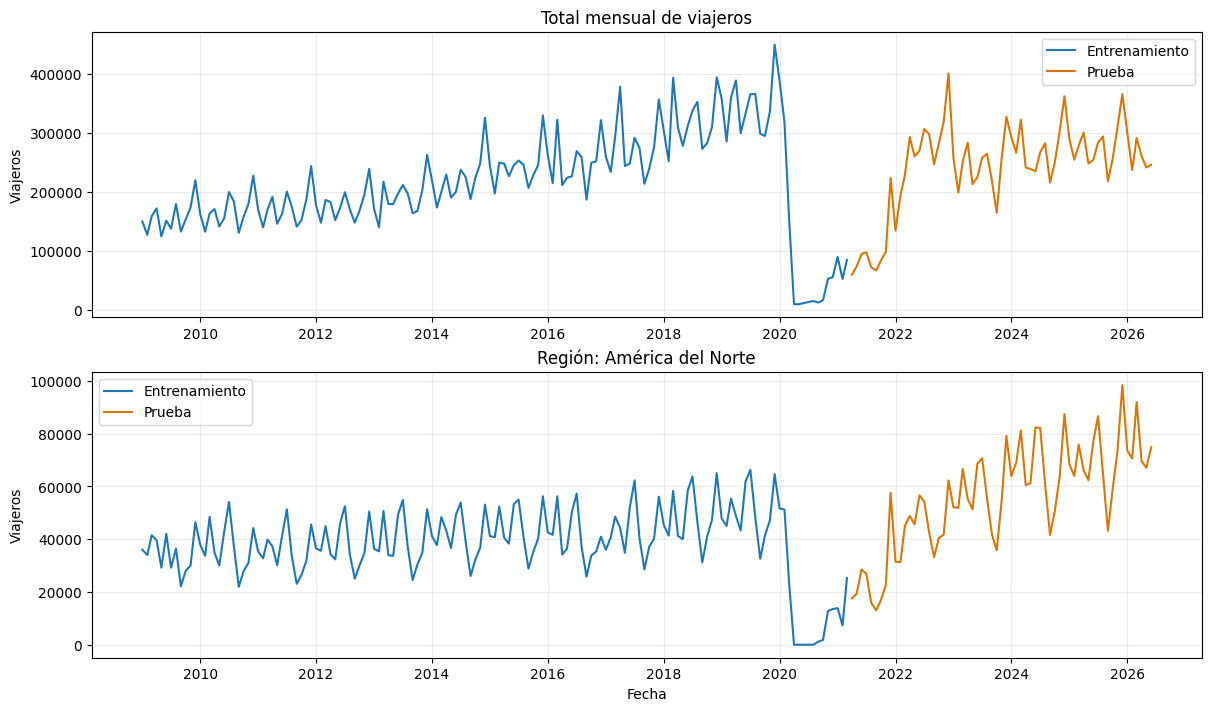

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
for ax, (nombre, serie) in zip(axes, series.items()):
    train, test = dividir_serie(serie)
    ax.plot(train.index, train.values, label="Entrenamiento", color="#1f77b4")
    ax.plot(test.index, test.values, label="Prueba", color="#d97706")
    ax.set_title(nombre)
    ax.set_ylabel("Viajeros")
    ax.grid(alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Fecha")
plt.show()

## 2. Modelos y tuneo de parámetros

Se evaluaron dos arquitecturas: una LSTM simple, con una capa recurrente, y una LSTM apilada, con dos capas recurrentes. Dentro de ambas se modificaron la ventana de entrada, la cantidad de unidades, el dropout, la tasa de aprendizaje y el tamaño de lote.

El último 20% de las secuencias de entrenamiento se utilizó como validación temporal. Las observaciones no se revolvieron y el conjunto de prueba no se utilizó para escoger la configuración.

In [4]:
@dataclass(frozen=True)
class ConfiguracionLSTM:
    nombre: str
    arquitectura: str
    ventana: int
    unidades_1: int
    unidades_2: int | None
    dropout: float
    learning_rate: float
    batch_size: int


configuraciones = [
    ConfiguracionLSTM("simple_01", "simple", 6, 32, None, 0.10, 0.0010, 16),
    ConfiguracionLSTM("simple_02", "simple", 12, 32, None, 0.20, 0.0010, 16),
    ConfiguracionLSTM("simple_03", "simple", 12, 64, None, 0.20, 0.0005, 8),
    ConfiguracionLSTM("apilada_01", "apilada", 6, 64, 32, 0.10, 0.0010, 16),
    ConfiguracionLSTM("apilada_02", "apilada", 12, 64, 32, 0.20, 0.0010, 16),
    ConfiguracionLSTM("apilada_03", "apilada", 12, 32, 16, 0.20, 0.0005, 8),
]

pd.DataFrame([asdict(config) for config in configuraciones])

,nombre,arquitectura,ventana,unidades_1,unidades_2,dropout,learning_rate,batch_size
0,simple_01,simple,6,32,NaN,0.1,0.0010,16
1,simple_02,simple,12,32,NaN,0.2,0.0010,16
2,simple_03,simple,12,64,NaN,0.2,0.0005,8
3,apilada_01,apilada,6,64,32.0,0.1,0.0010,16
4,apilada_02,apilada,12,64,32.0,0.2,0.0010,16
5,apilada_03,apilada,12,32,16.0,0.2,0.0005,8


In [5]:
def fijar_semilla():
    random.seed(SEMILLA)
    np.random.seed(SEMILLA)
    keras.utils.set_random_seed(SEMILLA)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def crear_ventanas(valores, ventana):
    x, y = [], []
    for i in range(ventana, len(valores)):
        x.append(valores[i - ventana:i])
        y.append(valores[i])
    return np.asarray(x, dtype="float32"), np.asarray(y, dtype="float32")


def construir_modelo(config):
    modelo = keras.Sequential()
    modelo.add(keras.layers.Input(shape=(config.ventana, 1)))
    if config.arquitectura == "simple":
        modelo.add(keras.layers.LSTM(config.unidades_1))
    else:
        modelo.add(keras.layers.LSTM(config.unidades_1, return_sequences=True))
        modelo.add(keras.layers.LSTM(config.unidades_2))
    modelo.add(keras.layers.Dropout(config.dropout))
    modelo.add(keras.layers.Dense(1))
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.learning_rate),
        loss="mse",
    )
    return modelo


def evaluar_configuracion(train, config, epochs=180):
    fijar_semilla()
    keras.backend.clear_session()
    scaler = MinMaxScaler()
    escalado = scaler.fit_transform(np.asarray(train).reshape(-1, 1))
    x, y = crear_ventanas(escalado, config.ventana)

    n_validacion = max(12, int(np.ceil(len(x) * 0.20)))
    x_train, x_val = x[:-n_validacion], x[-n_validacion:]
    y_train, y_val = y[:-n_validacion], y[-n_validacion:]

    modelo = construir_modelo(config)
    parada = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=18, restore_best_weights=True
    )
    historial = modelo.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=config.batch_size,
        shuffle=False,
        verbose=0,
        callbacks=[parada],
    )

    pred = scaler.inverse_transform(modelo.predict(x_val, verbose=0)).ravel()
    real = scaler.inverse_transform(y_val.reshape(-1, 1)).ravel()
    resultado = asdict(config)
    resultado.update({
        "mejor_epoca": int(np.argmin(historial.history["val_loss"]) + 1),
        "mae_validacion": mean_absolute_error(real, pred),
        "rmse_validacion": mean_squared_error(real, pred) ** 0.5,
    })
    return resultado


def pronosticar_test(train, test, config, epocas):
    fijar_semilla()
    keras.backend.clear_session()
    scaler = MinMaxScaler()
    escalado = scaler.fit_transform(np.asarray(train).reshape(-1, 1))
    x_train, y_train = crear_ventanas(escalado, config.ventana)

    modelo = construir_modelo(config)
    modelo.fit(
        x_train, y_train,
        epochs=max(1, epocas),
        batch_size=config.batch_size,
        shuffle=False,
        verbose=0,
    )

    historial = list(escalado[-config.ventana:, 0])
    predicciones = []
    for _ in range(len(test)):
        entrada = np.asarray(historial[-config.ventana:], dtype="float32")
        entrada = entrada.reshape(1, config.ventana, 1)
        siguiente = float(modelo.predict(entrada, verbose=0)[0, 0])
        predicciones.append(siguiente)
        historial.append(siguiente)

    predicciones = scaler.inverse_transform(
        np.asarray(predicciones).reshape(-1, 1)
    ).ravel()
    return np.clip(predicciones, 0, None)

### Resultados del tuneo

Se ajusta cada configuración por separado y se ordenan los resultados según el RMSE de validación. Un RMSE menor indica un mejor desempeño.

In [6]:
resultados_tuneo = []

for nombre, serie in series.items():
    train, _ = dividir_serie(serie)
    print(f"Tuneo: {nombre}")
    for config in configuraciones:
        resultado = evaluar_configuracion(train.to_numpy(), config)
        resultado["serie"] = nombre
        resultados_tuneo.append(resultado)
        print(f"  {config.nombre}: RMSE = {resultado['rmse_validacion']:,.0f}")

tuneo = pd.DataFrame(resultados_tuneo)
columnas = [
    "serie", "nombre", "arquitectura", "ventana", "unidades_1",
    "unidades_2", "dropout", "learning_rate", "batch_size",
    "mejor_epoca", "mae_validacion", "rmse_validacion",
]
tuneo[columnas].sort_values(["serie", "rmse_validacion"]).round(2)

Tuneo: Total mensual de viajeros


  simple_01: RMSE = 116,736


  simple_02: RMSE = 143,462


  simple_03: RMSE = 128,083


  apilada_01: RMSE = 114,971


...

  simple_03: RMSE = 19,795


  apilada_01: RMSE = 18,078


  apilada_02: RMSE = 20,050


  apilada_03: RMSE = 20,321


,serie,nombre,arquitectura,ventana,unidades_1,unidades_2,dropout,learning_rate,batch_size,mejor_epoca,mae_validacion,rmse_validacion
9,Región: América del Norte,apilada_01,apilada,6,64,32.0,0.1,0.0,16,5,14207.92,18077.99
6,Región: América del Norte,simple_01,simple,6,32,NaN,0.1,0.0,16,6,15509.82,19052.07
8,Región: América del Norte,simple_03,simple,12,64,NaN,0.2,0.0,8,4,14993.79,19795.45
10,Región: América del Norte,apilada_02,apilada,12,64,32.0,0.2,0.0,16,4,15945.41,20050.50
11,Región: América del Norte,apilada_03,apilada,12,32,16.0,0.2,0.0,8,2,17650.80,20320.55
7,Región: América del Norte,simple_02,simple,12,32,NaN,0.2,0.0,16,4,19068.41,21586.41
3,Total mensual de viajeros,apilada_01,apilada,6,64,32.0,0.1,0.0,16,25,77071.41,114970.80
0,Total mensual de viajeros,simple_01,simple,6,32,NaN,0.1,0.0,16,51,80972.05,116735.93
2,Total mensual de viajeros,simple_03,simple,12,64,NaN,0.2,0.0,8,4,96362.13,128083.36
4,Total mensual de viajeros,apilada_02,apilada,12,64,32.0,0.2,0.0,16,4,105501.34,131048.44


## 3. Predicción con el mejor modelo

Para cada serie se tomó la configuración con menor RMSE de validación. Luego se entrenó nuevamente con todas las observaciones de entrenamiento y se pronosticaron los 63 meses de prueba de manera recursiva.

In [7]:
filas_metricas = []
filas_predicciones = []

for nombre, serie in series.items():
    train, test = dividir_serie(serie)
    mejor = (
        tuneo[tuneo["serie"] == nombre]
        .sort_values("rmse_validacion")
        .iloc[0]
    )
    config = next(c for c in configuraciones if c.nombre == mejor["nombre"])
    pred = pronosticar_test(
        train.to_numpy(), test.to_numpy(), config, int(mejor["mejor_epoca"])
    )

    mae = mean_absolute_error(test, pred)
    rmse = mean_squared_error(test, pred) ** 0.5
    denominador = np.abs(test.to_numpy()) + np.abs(pred)
    smape = np.mean(
        np.divide(
            2 * np.abs(pred - test.to_numpy()),
            denominador,
            out=np.zeros_like(denominador),
            where=denominador != 0,
        )
    ) * 100

    filas_metricas.append({
        "Serie": nombre,
        "Mejor configuración": config.nombre,
        "Arquitectura": config.arquitectura,
        "Ventana": config.ventana,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape,
    })
    for fecha, real, estimado in zip(test.index, test.to_numpy(), pred):
        filas_predicciones.append({
            "Serie": nombre,
            "Fecha": fecha,
            "Real": real,
            "Predicción": estimado,
        })

metricas = pd.DataFrame(filas_metricas)
predicciones = pd.DataFrame(filas_predicciones)
metricas.round(2)

,Serie,Mejor configuración,Arquitectura,Ventana,MAE,RMSE,sMAPE (%)
0,Total mensual de viajeros,apilada_01,apilada,6,74089.96,85804.50,34.39
1,Región: América del Norte,apilada_01,apilada,6,26247.47,30752.14,54.87


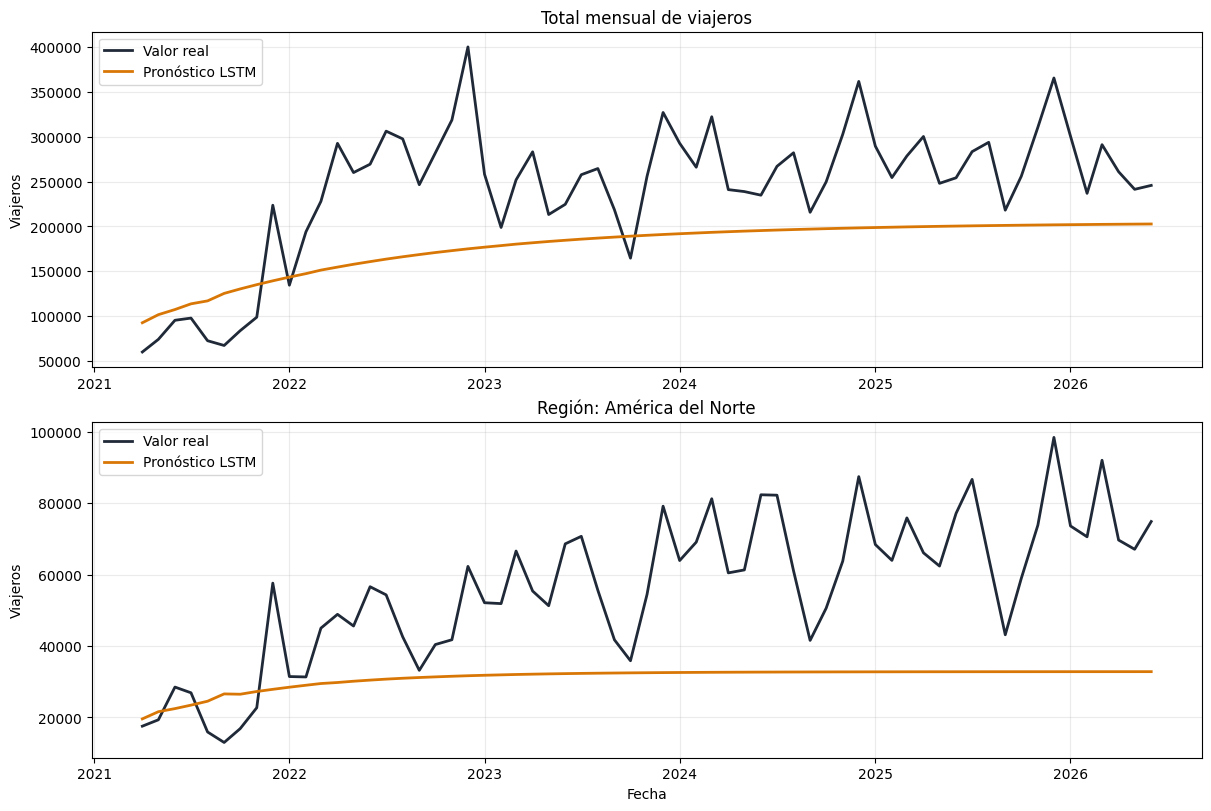

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
for ax, nombre in zip(axes, series):
    datos = predicciones[predicciones["Serie"] == nombre]
    ax.plot(datos["Fecha"], datos["Real"], label="Valor real", color="#1f2937", linewidth=2)
    ax.plot(datos["Fecha"], datos["Predicción"], label="Pronóstico LSTM", color="#d97706", linewidth=2)
    ax.set_title(nombre)
    ax.set_ylabel("Viajeros")
    ax.grid(alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Fecha")
plt.show()

## 4. Resultados preliminares

En las dos series la mejor configuración fue la LSTM apilada con una ventana de seis meses, 64 unidades en la primera capa, 32 en la segunda y dropout de 0.10.

- Para el total mensual de viajeros se obtuvo un MAE aproximado de 74,090 y un RMSE de 85,805.
- Para América del Norte se obtuvo un MAE aproximado de 26,247 y un RMSE de 30,752.

El pronóstico sigue la recuperación general posterior a 2021, pero suaviza los picos mensuales. Esto ocurre porque se están pronosticando 63 meses de forma recursiva desde un entrenamiento que termina durante la pandemia. Para esta entrega se deja documentado el tuneo de las redes LSTM, las comparaciones completas y catch22 se desarrollarán posteriormente.